# Perceptron for OCR - MNIST Digit Recognition

This notebook implements a Convolutional Neural Network (CNN) for recognizing handwritten digits from the MNIST dataset using PyTorch and PyTorch Lightning.

## About the MNIST Dataset
The MNIST (Modified National Institute of Standards and Technology) dataset consists of 70,000 small square 28×28 pixel grayscale images of handwritten single digits between 0 and 9. The dataset is divided into 60,000 training images and 10,000 testing images.

## What We'll Accomplish
In this notebook, we will:
1. Install and import necessities
2. Hyperparameter configuration
3. Visualize the dataset
4. Learn and load a model
5. Test the model
6. Visualize results

The model architecture uses convolutional layers, batch normalization, and dropout for regularization to achieve high accuracy (>99% on the test set).

## Key Features
- Data augmentation for improved model robustness
- Convolutional neural network architecture
- Batch normalization and dropout for regularization
- Learning rate scheduling
- Model checkpointing and monitoring with Weights & Biases (WandB)
- Test evaluation

## My setup
It is nice to have an approximation on how long it will take. Unfortunately I cannot provide this since it is heavily dependent on your own hardware.
Time approximations further down the notebook are entirely based on my current hardware:
- GPU: 24GB of VRAM
- CPU: 10 Cores, 4.1Ghz
- DRAM: 2x8GB, DDR4, 3200Mhz

# Setting notebook configurations

Before we begin with anything, lets first settle on what you would like to achieve in this notebook.
Learning and tuning a model can take some time so make sure not to skip this step!

- If you want to use a pre trained model, leave all of the below as False. 
- Setting both to True is reduntant. 
In code, tuning occurs before training a new model, so your model selected for evaluation will be the last one and your tuning will have been for nothing.
Pick either one.


Time approximations:
- Picking a pre-trained model ~No additional time.
- Training a new model ~5-10 minutes.
- Tuning the hyperparameters with 20 trials ~1 hour.

In [1]:
i_want_to_train_a_new_model = True
i_want_to_tune_hyperparameters = False

## Imports and Setup

Before we begin building our model, we need to import the necessary libraries and set up our environment. The following cells installs any dependencies and imports the neccesary packages.

In [2]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


I decided not to import any functions, variables or classes here.
I instead imported them in the codeblocks that they are used.

I did this to make it clearer from where exactly we are getting the code.
This allows for easier navigation when reading and executing the notebook.

In [3]:
import os
import glob
import numpy as np
import torch
from torchvision import transforms
import matplotlib.pyplot as plt

# Manual seed
torch.manual_seed(42)
np.random.seed(42)

#GPU availability and tensor core optimization
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    torch.set_float32_matmul_precision("high")
    
# Output directory
os.makedirs("checkpoints", exist_ok=True)



Using device: cuda


## Hyperparameter Configuration

Hyperparameters are imported from a separate file.
They are then overwritten with the same values below. This is done to make it very clear what parameters we are using and that they can be changed at any time.
This creates an easy point in the notebook for users to tune the model how they like.

The values chosen here represent a configuration that has been proven to achieve high accuracy (>99%) on the MNIST dataset.

In [4]:
from src.config.hyperparameters import hyperparameters as hp

# MODEL ARCHITECTURE PARAMETERS
hp["input_size"] = 784
hp["hidden_size"] = 128
hp["output_size"] = 10
hp["conv_channels1"] = 64
hp["conv_channels2"] = 128
hp["conv_channels3"] = 256
hp["kernel_size"] = 3
hp["fc_size"] = 128    

# TRAINING PARAMETERS
hp["learning_rate"] = 1e-3
hp["weight_decay"] = 5e-6
hp["dropout_rate"] = 0.3
hp["max_epochs"] = 40
hp["batch_size"] = 64
hp["val_batch_size"] = 128

# DATA PARAMETERS
hp["val_split"] = 0.1667

# PATHS AND OTHER SETTINGS
hp["checkpoints_dir"] = "checkpoints"
hp["wandb_project"] = "pytorch-mnist-ocr"
hp["device"] = "cuda" if torch.cuda.is_available() else "cpu"

# HYPER PARAMETER TUNING
hp["optuna_trials"] = 20
hp["study_name"] = "optuna_study"
hp["storage"] = "sqlite:///optuna_studies.db"

## Visualizing augmentation

I decided to use the following augmentation techniques:
- RandomAffine (10 degrees, 0.1 translation, 0.85-1.05 scaling)
- ElasticTransform (alpha=50.0, sigma=5.0)
- ColorJitter (brightness=0.2, contrast=0.2)
- Normalize (0.5, 0.5)

Data augmentation in a nutshell is a technique that distorts, twists and transforms the data on which we train our model on.
We do this to make our model perform better on unseen data.
Initially this might actually lower the accuracy of our model when first implemented.
We can also use augmentation to increase the size of our dataset even though I decided not to do this here.

The code below augments the data and creates 10 plots for each digit.
Once the plots have been drawn they will show up on screen.


<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/home/appuser/.local/lib/python3.10/site-packages/matplotlib/pyplot.py'>
<module 'matplotlib.pyplot' from '/ho

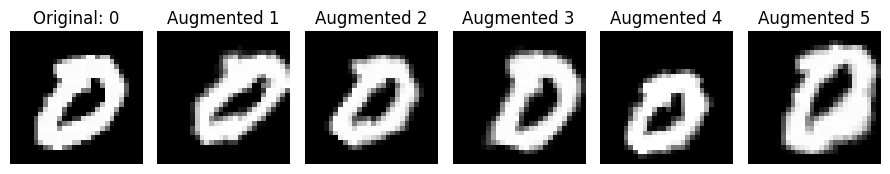

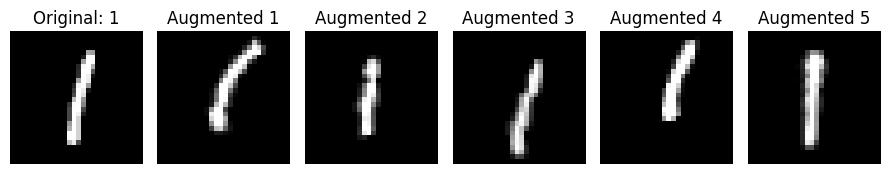

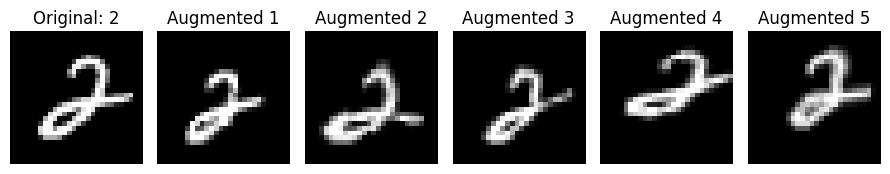

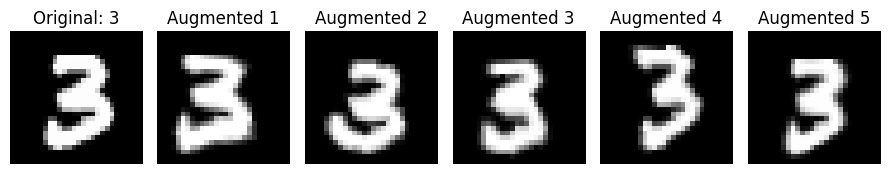

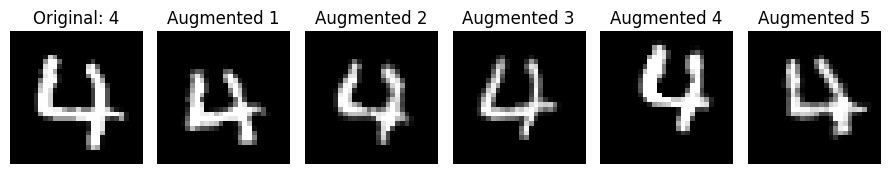

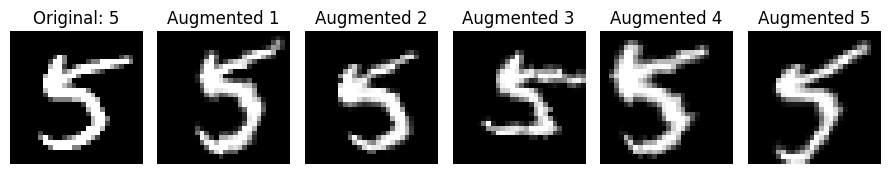

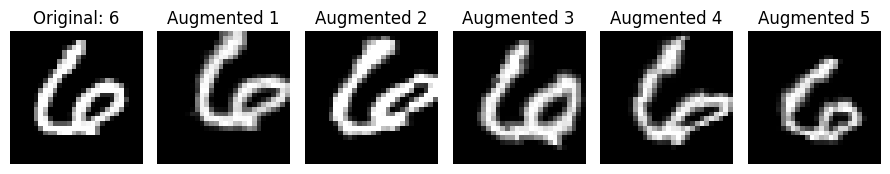

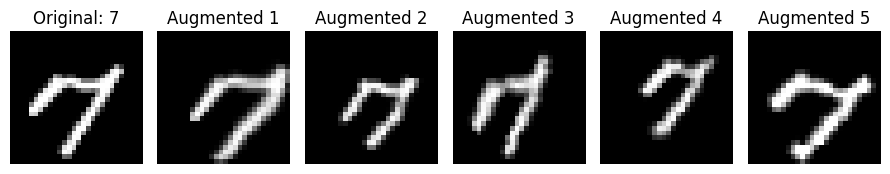

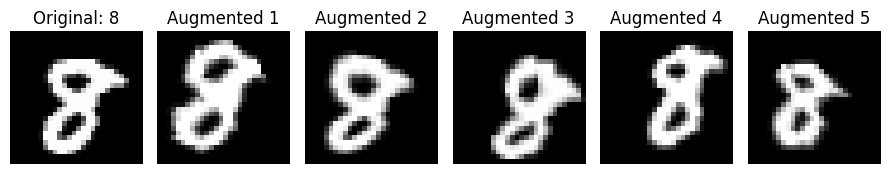

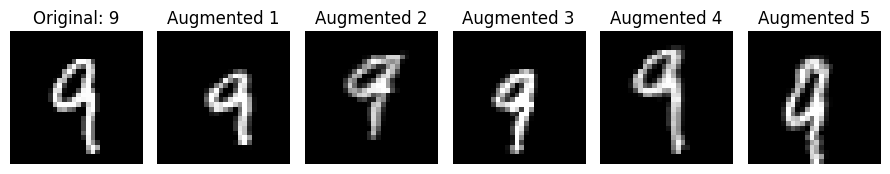

In [5]:
from src.data.augmentation import visualize_augmentations

# Visualize augmentations for each digit 0-9
for digit in range(10):
    print(visualize_augmentations(digit=digit))

This visualization demonstrates how data augmentation creates variations of the training data, which helps the model generalize better to unseen examples. The transformations include:

These augmentations help the model become more robust to variations in the input data, reducing overfitting and improving generalization to real-world examples.

## The network

The model architecture can be summarized as follows:

1. **Convolutional Layers:**
   - Three convolutional layers with increasing filter counts (64, 128, 256)
   - Batch normalization after each convolutional layer for faster and more stable training
   - ReLU activation functions to introduce non-linearity
   - Max pooling to reduce spatial dimensions and increase the field of view

2. **Fully Connected Layers:**
   - After flattening the output of the convolutional layers, we have two fully connected layers
   - Dropout between fully connected layers to prevent overfitting
   - Final layer outputs logits for each of the 10 possible digits

3. **PyTorch Lightning Integration:**
   - Organized training and validation steps
   - Learning rate scheduling based on validation accuracy
   - Metrics tracking for monitoring training progress

This architecture provides a good balance between complexity and performance, allowing the model to learn useful representations of the handwritten digits while avoiding overfitting.

The actual class is defined in src/models/network.py

# Training & Tuning Execution


The code below will, depending on your previous choices

In [6]:
from src.training.trainer import (
    load_model_from_checkpoint,
    train_model
)
from src.optimization.hyperparameter_tuning import (
    run_optuna_study, 
    visualize_study_results
)

if i_want_to_tune_hyperparameters:
    study = run_optuna_study(
        n_trials=hp["optuna_trials"],
        study_name=hp["study_name"],
        storage=hp["storage"]
    )
    visualize_study_results(study)

    best_n = study.best_trial.number
    pattern = f"checkpoints/trial-{best_n}-*.ckpt"
    files = glob.glob(pattern)

    if files:
        path = files[0]
        model = load_model_from_checkpoint(path)
    else:
        print(
            f"No checkpoint found for optuna trial {best_n}.\n"
            "Defaulting to the latest model..."
        )
        model = load_model_from_checkpoint()


if i_want_to_train_a_new_model:
    model, checkpoint_path = train_model(hparams=hp)
else:
    model = load_model_from_checkpoint()


print("Model ready for evaluation and testing!")

Starting model training...
Dataset split: 49998 training samples (with augmentation), 10002 validation samples (no augmentation).
Batch sizes: training=64, validation=128


wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

  ········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /home/appuser/.netrc
wandb: Currently logged in as: felix-soderstrom (felix-soderstrom-teknikh-gskolan) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: logging graph, to disable use `wandb.watch(log_graph=False)`
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


...

Validation: 0it [00:00, ?it/s]

Epoch 39, global step 31280: 'val_acc' was not in top 1
`Trainer.fit` stopped: `max_epochs=40` reached.


Found checkpoint: checkpoints/avid-plant-93-epoch=32-val_acc=0.9960.ckpt


epoch,▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train_acc,▁▅▆▆▇▇▇▇▇▇▇▇▇███████████████████████████
train_loss,█▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█████
val_acc,▁▃▄▄▆▆▆▆▆▇▇▇▇▇▇▇▇█▇██▇████▇█████████████
val_loss,█▆▅▅▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,39
train_acc,0.995
train_loss,0.01772
trainer/global_step,31279
val_acc,0.9956


Training complete! Best model saved to: checkpoints/avid-plant-93-epoch=32-val_acc=0.9960.ckpt
Model ready for evaluation and testing!


# Understanding hyperparameter-tuning

I'm using Optuna to tune the model. This is synced with WandB and compatible with PyTorch Lightning.
Optuna initiates training new models with different hyperparameters and compares the results.
When the above cell is running you will see output similar to the on when training a new model (this is exactly what it's doing!) but this will happen several times.

Several files and folders will now appear in your codebase.
Here is the explanation in a nutshell:
- In your checkpoints directory there will now be several folders named 'trial'. The models produced in this hyperparameter tuning will be palced in its own subdirectory.
- optuna_results directory appears and within you can find study_summary.txt. This is a text file made for human eyes. Here you can read everything about the tuning you just performed.
- optuna_studies.db is a SQLlite file that stores history from each trial Optuna performs. Optuna uses this to compare models and choose hyperparameters for the next run accordingly.

### Understanding the Training Output

When running the training, you'll see output similar to this:
```
Training on GPU
Epoch 0: 100%|██████████| 782/782 [00:10<00:00, 73.87it/s, v_num=05ef, val_loss=0.148, val_acc=0.965, train_loss=0.967, train_acc=0.783]
Epoch 0, global step 782: 'val_acc' reached 0.96481 (best 0.96481), saving model to 'C:/Path/checkpoint.ckpt' as top 1
...
```

When a new best validation accuracy is reached, that model overrides the previous top one in the checkpoints directory.
WandB will handle metric logging and all of this can be viewed in your browser at [WandB's website](https://wandb.ai/)

## Comparing checkpoints

The code below will list all available checkpoints and compare their performance.
This is useful for long-term model development, where you might train multiple models with different configurations and need to compare their performance.

1. **Listing Checkpoints**: We can see all available checkpoints with their metadata
2. **Deleting Checkpoints**: Seeing this comparison enables us to delete old or unnecessary checkpoints to save disk space
3. **Cleaning Up**: We can keep only the most recent or best-performing checkpoints
4. **Comparing Performance**: We can evaluate multiple checkpoints on the test set to find the best one

**IMPORTANT NOTICE ABOUT THIS CELL**
When transitioning to docker I had to downgrade Python version and therefore the PyTorch Lightning version aswell.
This shows up as a warning when trying to load my pre-trained models (The model you are trying to load was created with and older version of PyTorch Lightning...).
This does not affect the functionality of the notebook and the models can still be evaluated without errors in the Linux environment.

Found 4 checkpoint(s):
  1. avid-plant-93-epoch=32-val_acc=0.9960.ckpt
     Run: avid-plant-93, Epoch: epoch=32, Accuracy: val_acc=0.9960
     Last Modified: Tue May 13 13:22:33 2025
  2. trial-19(automated tuning)-epoch=36-val_acc=0.9960.ckpt
     Run: trial-19(automated tuning), Epoch: epoch=36, Accuracy: val_acc=0.9960
     Last Modified: Tue May 13 08:31:43 2025
  3. trial-13(automated tuning)-epoch=37-val_acc=0.9963.ckpt
     Run: trial-13(automated tuning), Epoch: epoch=37, Accuracy: val_acc=0.9963
     Last Modified: Mon May 12 19:24:19 2025
  4. holographic-admiral(manual tuning)-26-epoch=39-val_acc=0.9970.ckpt
     Run: holographic-admiral(manual tuning)-26, Epoch: epoch=39, Accuracy: val_acc=0.9970
     Last Modified: Sat May 10 17:56:10 2025
Test dataset: 10000 samples
Lightning Checkpoint loaded from checkpoints/avid-plant-93-epoch=32-val_acc=0.9960.ckpt to cuda
Checkpoint: avid-plant-93-epoch=32-val_acc=0.9960.ckpt
Test Accuracy: 99.6200%
----------------------------------

/home/appuser/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/migration/utils.py:55: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v2.0.9
  rank_zero_warn(


Checkpoint: trial-19(automated tuning)-epoch=36-val_acc=0.9960.ckpt
Test Accuracy: 99.7100%
--------------------------------------------------
Lightning Checkpoint loaded from checkpoints/trial-13(automated tuning)-epoch=37-val_acc=0.9963.ckpt to cuda
Checkpoint: trial-13(automated tuning)-epoch=37-val_acc=0.9963.ckpt
Test Accuracy: 99.6300%
--------------------------------------------------
Lightning Checkpoint loaded from checkpoints/holographic-admiral(manual tuning)-26-epoch=39-val_acc=0.9970.ckpt to cuda


/home/appuser/.local/lib/python3.10/site-packages/pytorch_lightning/utilities/migration/utils.py:55: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.5.1, which is newer than your current Lightning version: v2.0.9
  rank_zero_warn(


Checkpoint: holographic-admiral(manual tuning)-26-epoch=39-val_acc=0.9970.ckpt
Test Accuracy: 99.6500%
--------------------------------------------------

Best checkpoint: trial-19(automated tuning)-epoch=36-val_acc=0.9960.ckpt
Test Accuracy: 99.7100%


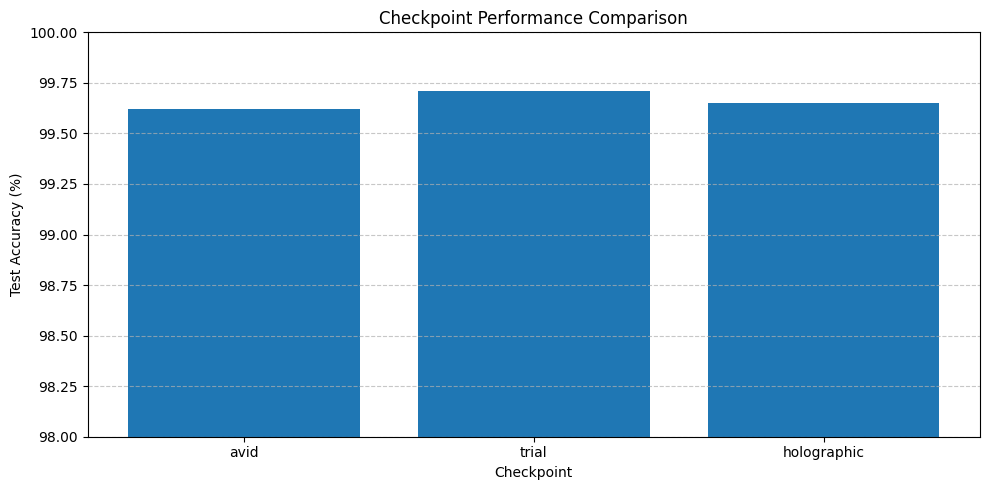

In [7]:
from src.training.trainer import list_all_checkpoints, compare_checkpoints

# List all available checkpoints
checkpoint_files = list_all_checkpoints()

# If we have multiple checkpoints, we can compare their performance
if len(checkpoint_files) > 1:
    results = compare_checkpoints(checkpoint_files[:5])
    
    # Visualize the comparison
    plt.figure(figsize=(10, 5))
    plt.bar(
        [os.path.basename(cp).split('-')[0] for cp in results.keys()], 
        list(results.values())
    )
    plt.xlabel('Checkpoint')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Checkpoint Performance Comparison')
    plt.ylim(98, 100)  # Typical range for MNIST accuracy
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Model Evaluation

Now that we have our trained model, let's evaluate its performance on the test dataset and analyze the results in detail. This will help us understand how well our model generalizes to unseen data and identify areas where it might struggle.

The code below will benchmark the model on the test-data and visualize:
- Test Accuracy
- Confusion Matrix
- Misclassified Examples
- Model Confidence
- Average Probability distribution
- Per-class Accuracy

Test dataset: 10000 samples
Test Accuracy: 99.6400%

Per-class Accuracy:
  Digit 0: 99.7959%
  Digit 1: 99.6476%
  Digit 2: 99.7093%
  Digit 3: 99.6040%
  Digit 4: 99.8982%
  Digit 5: 99.6637%
  Digit 6: 99.3737%
  Digit 7: 99.6109%
  Digit 8: 99.5893%
  Digit 9: 99.5045%

Total correct classifications: 9964 out of 10000
Total errors: 36
Test dataset: 10000 samples

Visualizing misclassified examples:


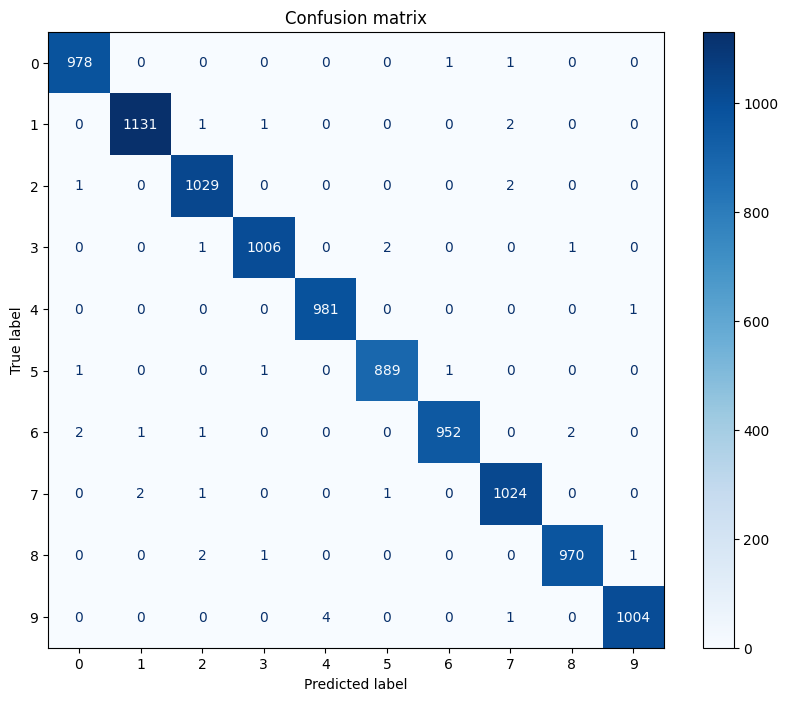

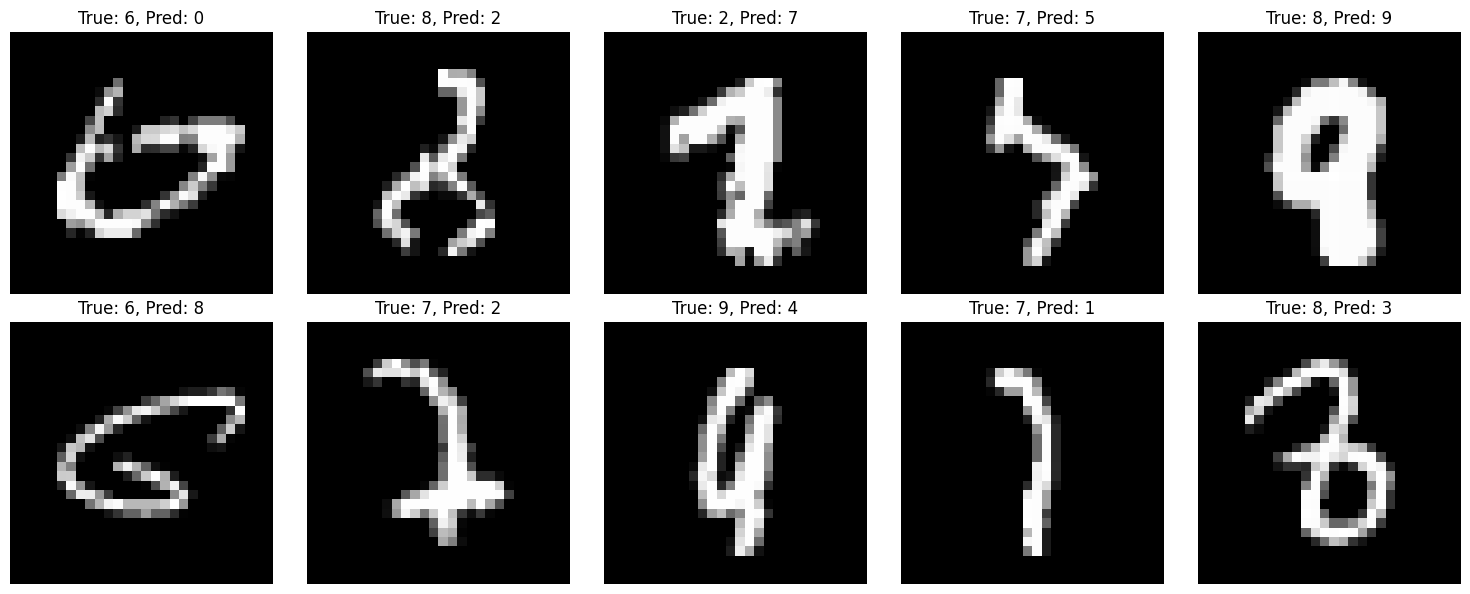

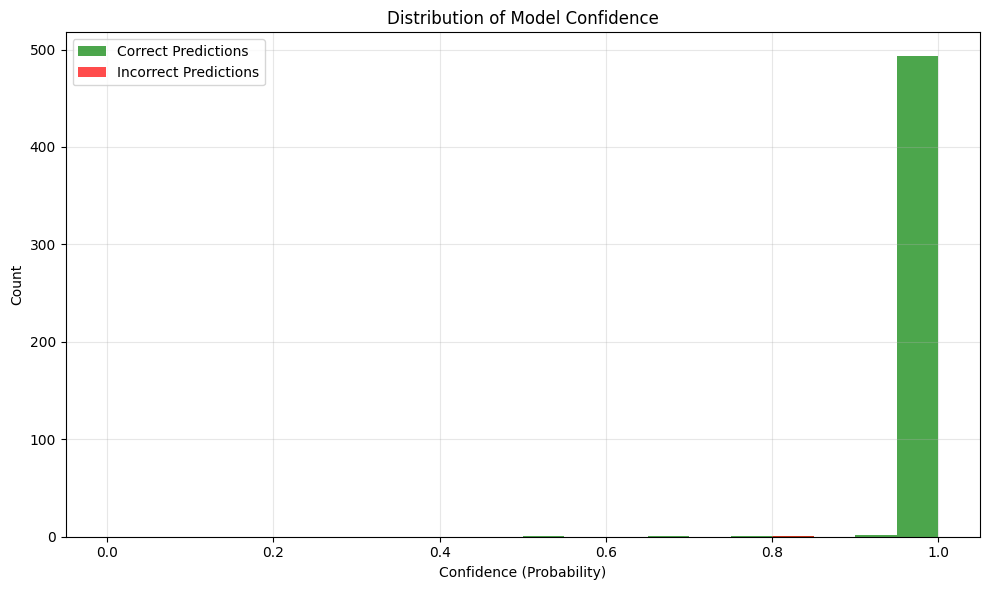

Average confidence for correct predictions: 0.9969
Average confidence for incorrect predictions: 0.8276


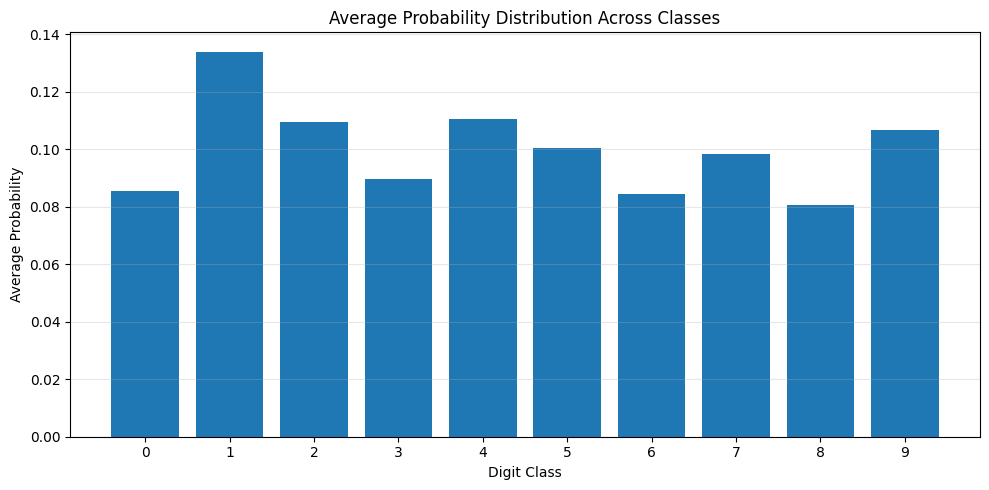

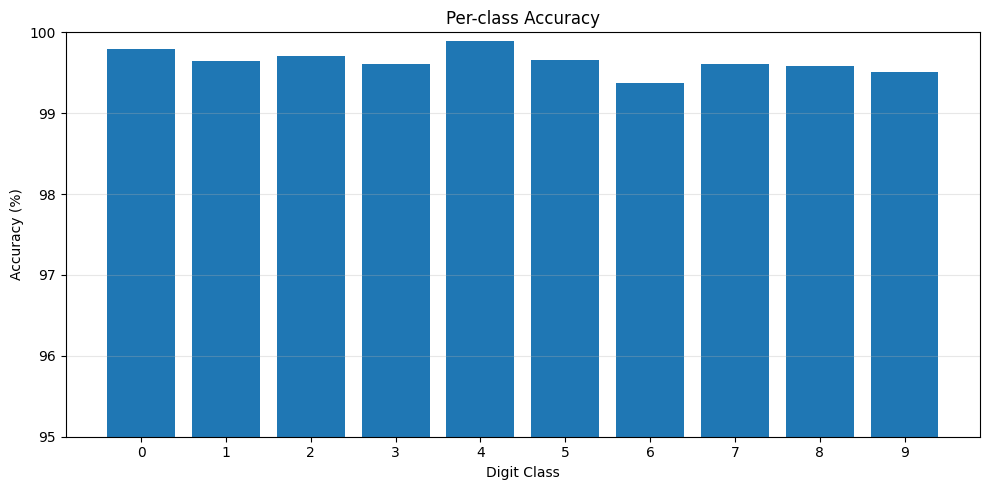

In [8]:
from src.data.data_loader import load_test_dataset
from src.evaluation.evaluation import evaluate_model, analyze_model_confidence
from src.visualization.visualization import plot_confusion_matrix, visualize_errors




# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# Load the test dataset
test_loader = load_test_dataset()

# Evaluate the model
accuracy, confusion_mat, class_accuracies, error_indices = evaluate_model(model, test_loader)

# Plot confusion matrix
plot_confusion_matrix(model)

# Visualize some misclassified examples
if error_indices:
    print("\nVisualizing misclassified examples:")
    visualize_errors(model, error_indices, n_examples=10)
else:
    print("No misclassified examples found!")

# Analyze model confidence
avg_probs, correct_conf, incorrect_conf = analyze_model_confidence(model, test_loader)

# Plot per-class accuracy
plt.figure(figsize=(10, 5))
plt.bar(range(hp["output_size"]), class_accuracies)
plt.xlabel('Digit Class')
plt.ylabel('Accuracy (%)')
plt.title('Per-class Accuracy')
plt.xticks(range(hp["output_size"]))
plt.ylim([95, 100])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

This comprehensive evaluation provides several insights into our model's performance:

1. **Overall Accuracy**: The proportion of correctly classified digits in the test set.

2. **Per-class Accuracy**: How well the model performs on each digit class, which helps identify digits the model struggles with.

3. **Confusion Matrix**: Shows which digits are most commonly confused with each other.

4. **Error Analysis**: Visualizing misclassified examples helps understand what types of digits are challenging for the model.

5. **Confidence Analysis**: 
   - For correct predictions, high confidence indicates the model is certain about its correct answers.
   - For incorrect predictions, high confidence indicates overconfidence in errors.
   - The difference between confidence in correct vs. incorrect predictions indicates how well-calibrated the model is.

These evaluation metrics provide a much deeper understanding of the model's behavior than just the overall accuracy number, helping guide further improvements to the architecture or training process. 

## Prediction Visualization

One of the most intuitive ways to understand how well our model performs is to visualize its predictions on actual images. This section will visualize how the model "sees" the MNIST digits and what features it finds most important for classification.

Let's visualize how our model performs on random samples:

Visualizing model predictions on random test samples:
Test dataset: 10000 samples

Probability distribution for a digit 3:


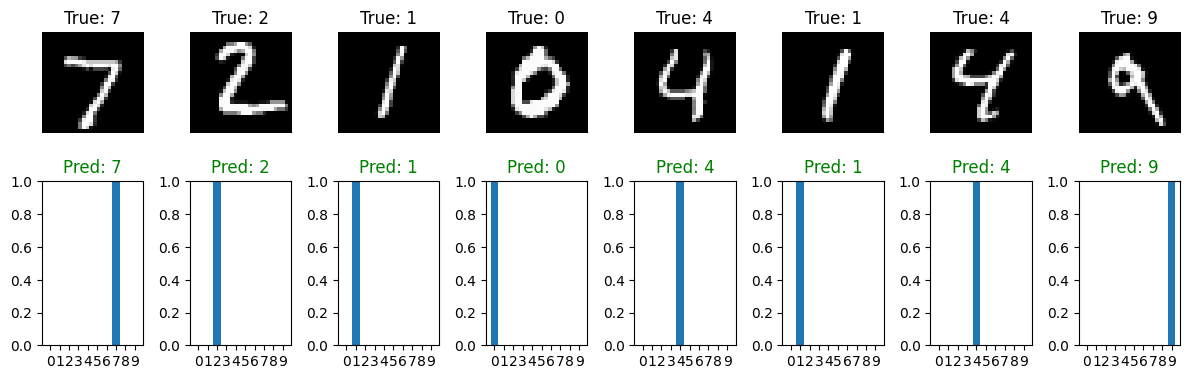

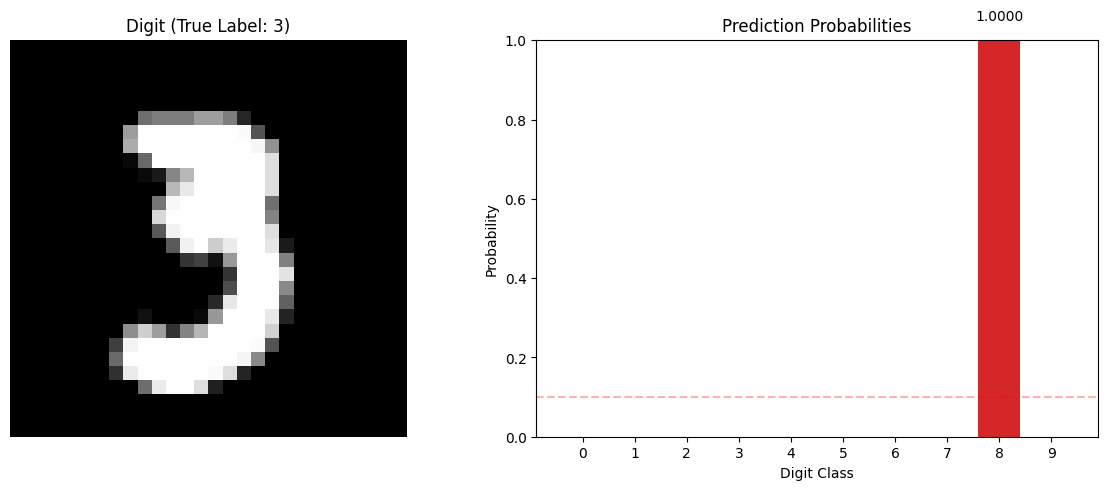


Probability distribution for a digit 8:


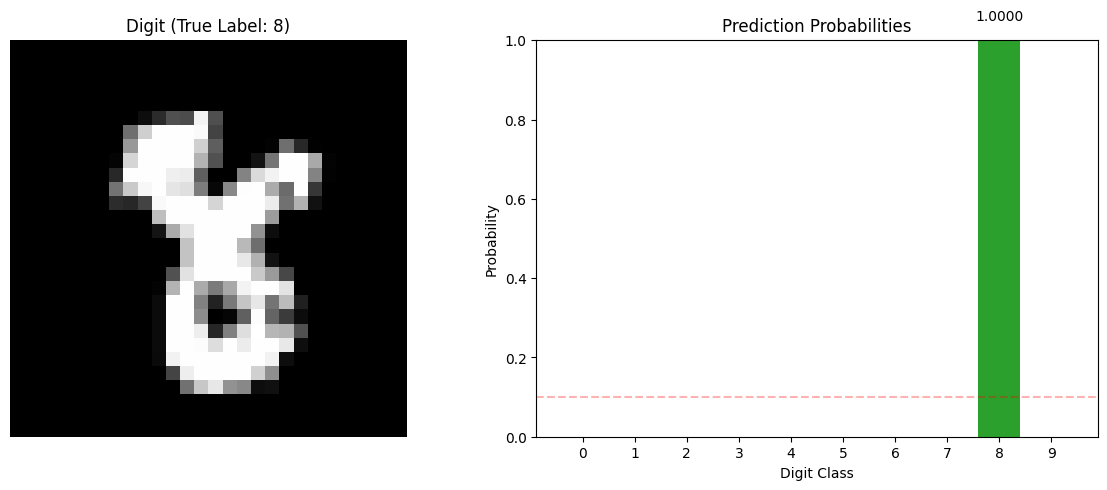


Visualizing feature maps from the first convolutional layer:

Creating a grid of random digits with predictions:


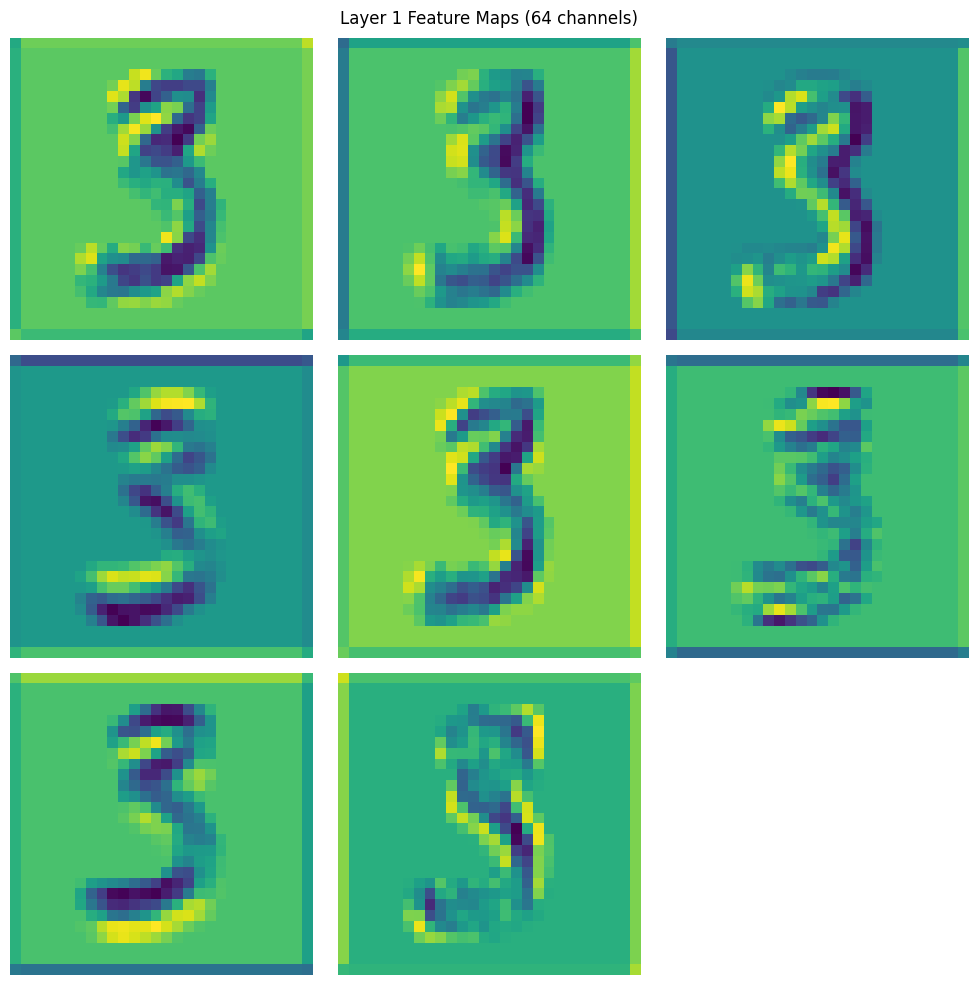

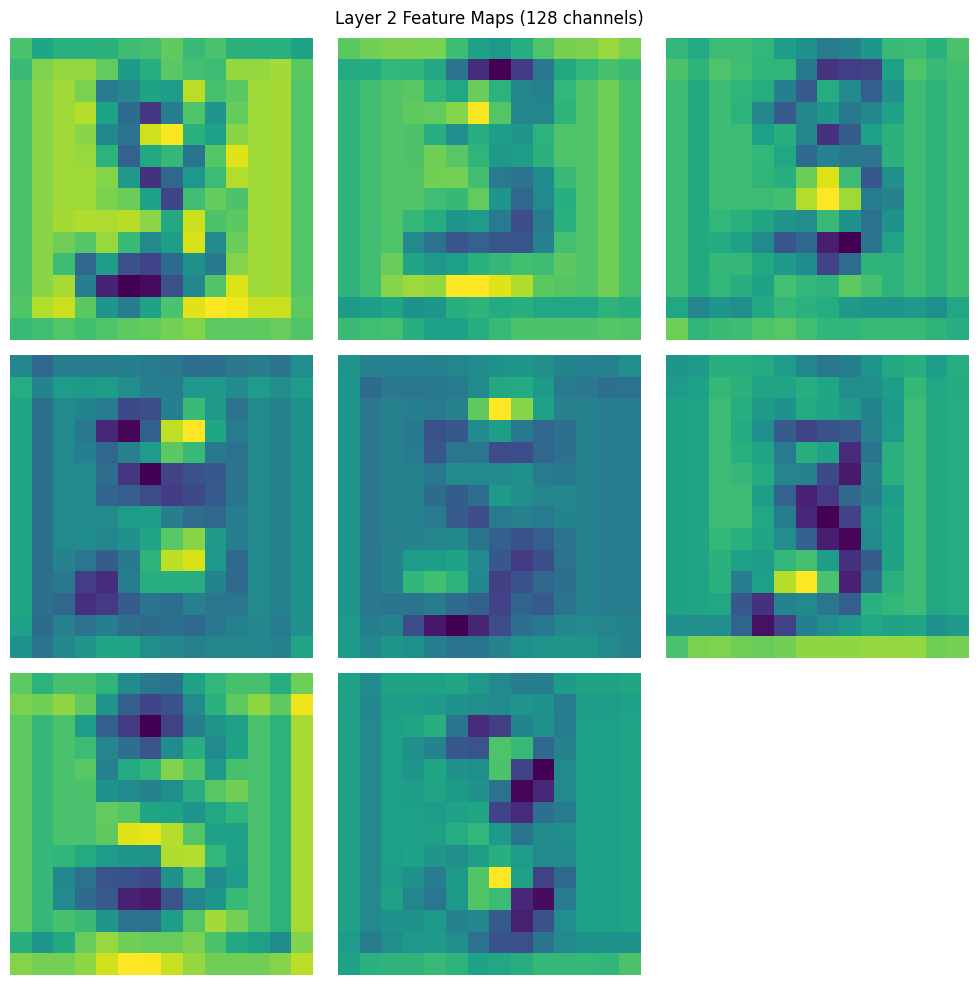

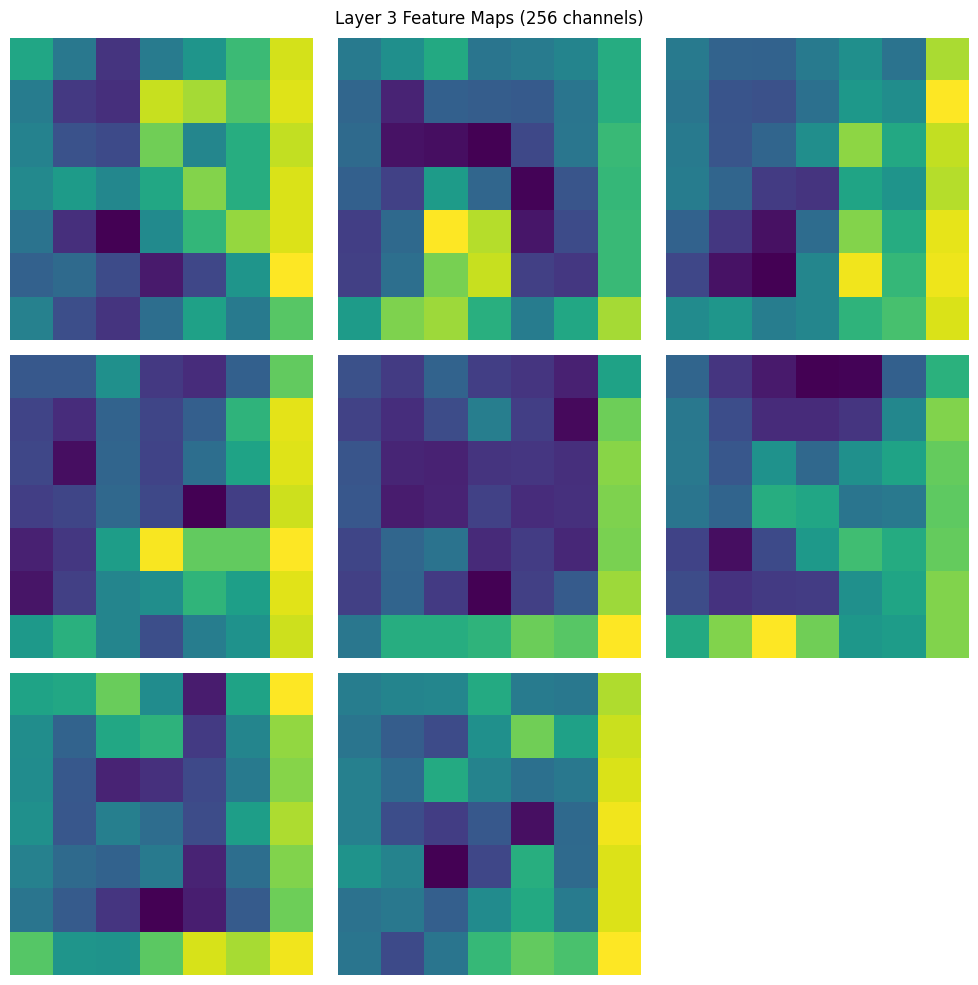

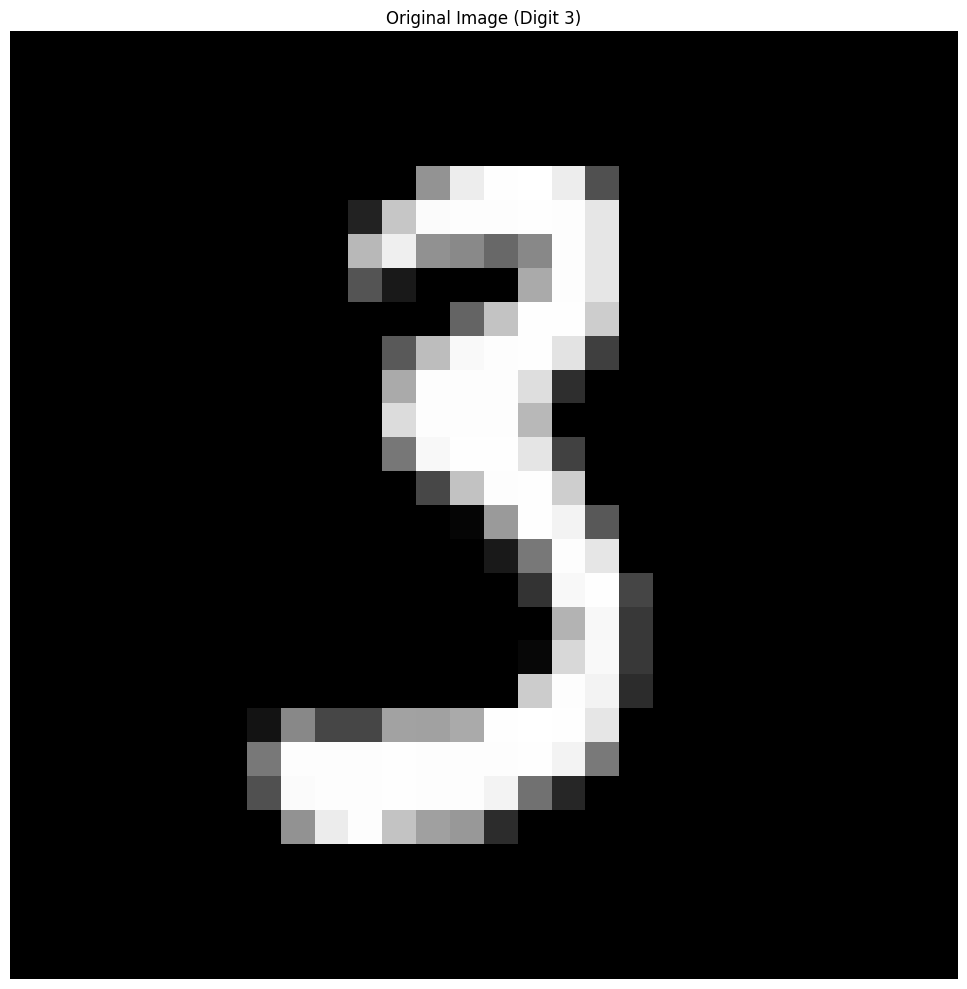

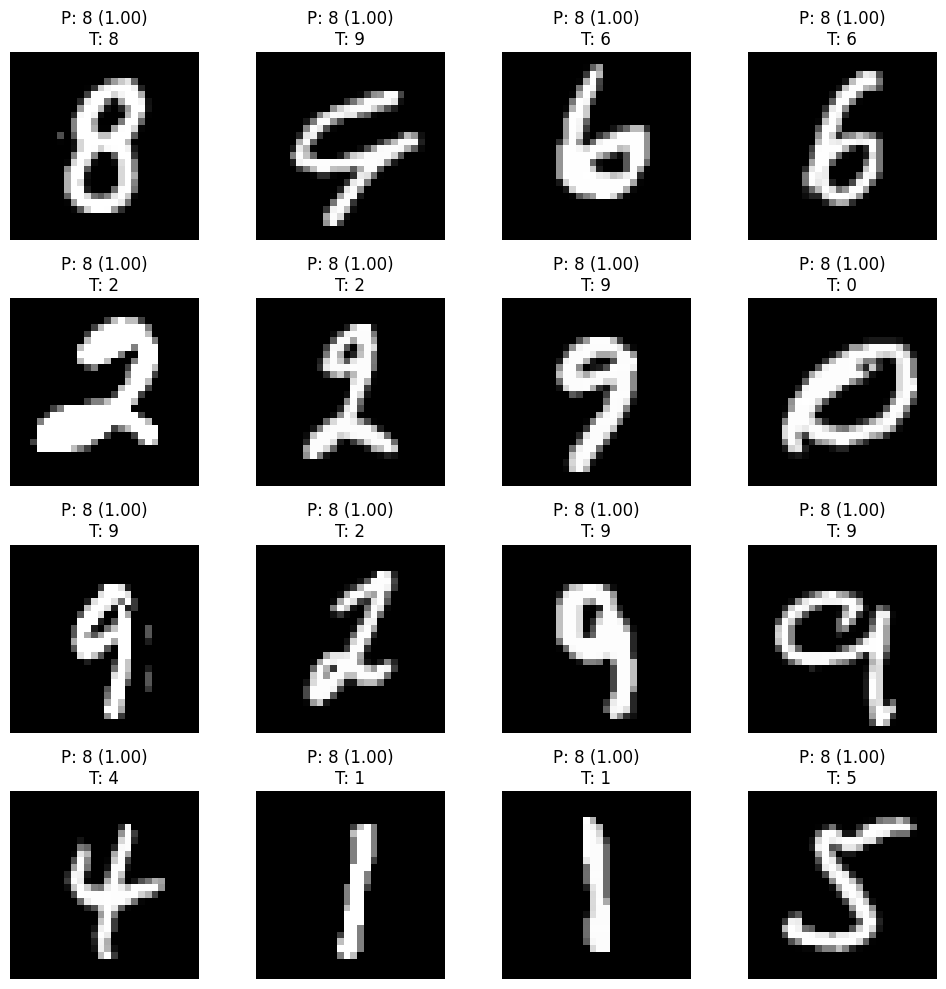

Test dataset: 10000 samples
Test Accuracy: 99.6400%

Per-class Accuracy:
  Digit 0: 99.7959%
  Digit 1: 99.6476%
  Digit 2: 99.7093%
  Digit 3: 99.6040%
  Digit 4: 99.8982%
  Digit 5: 99.6637%
  Digit 6: 99.3737%
  Digit 7: 99.6109%
  Digit 8: 99.5893%
  Digit 9: 99.5045%

Total correct classifications: 9964 out of 10000
Total errors: 36


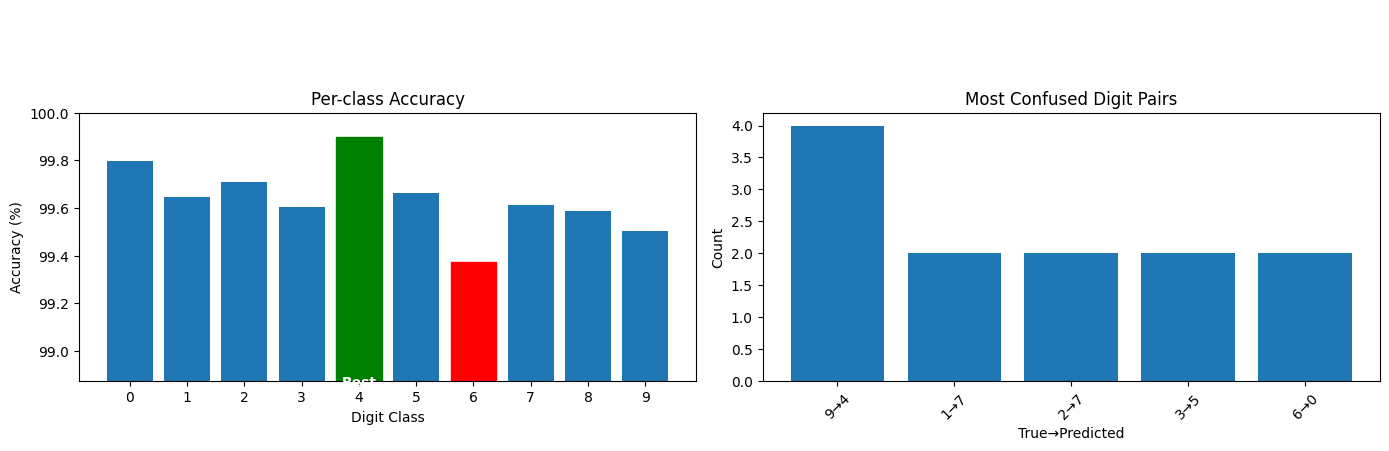

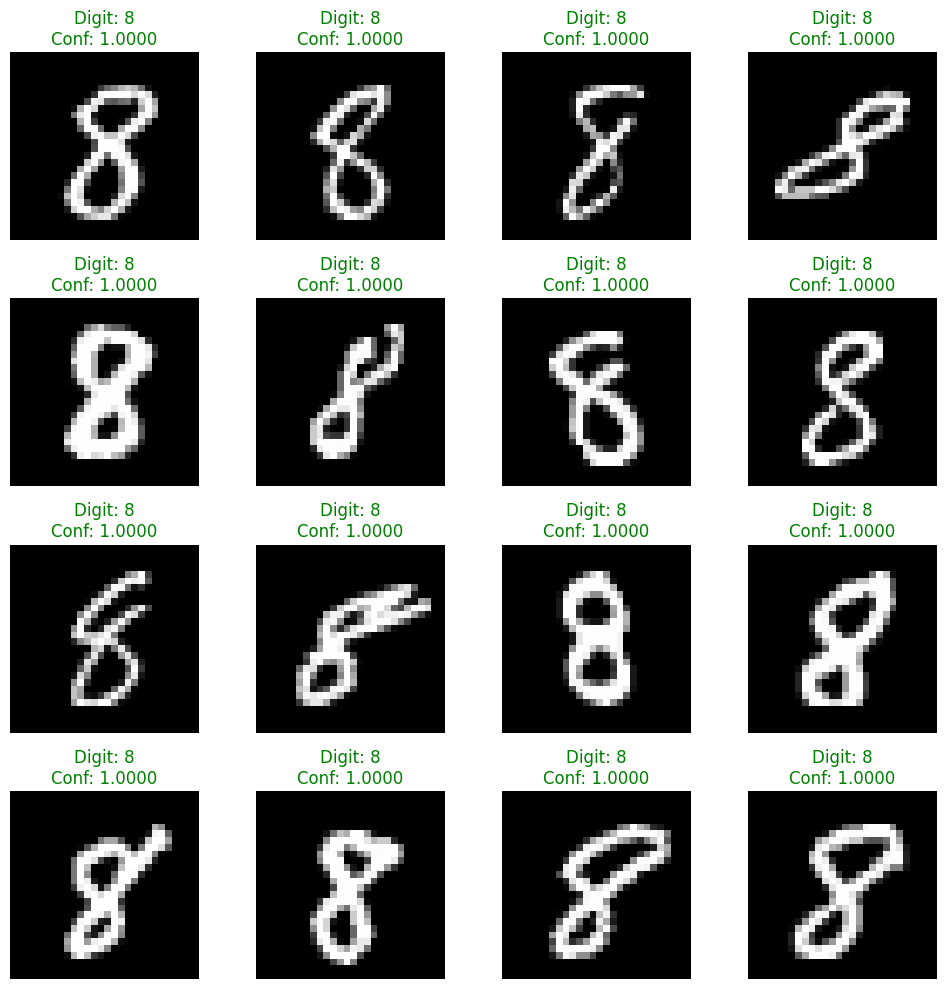

In [9]:
from src.data.data_loader import get_dataset
from src.visualization.visualization import (
    visualize_predictions, 
    plot_digit_probabilities, 
    visualize_feature_maps, 
    create_digit_grid
)
from src.evaluation.evaluation import summarize_model_performance
from src.visualization.visualization import plot_summary_graphs
from src.visualization.visualization import show_successful_predictions


# Make sure we have a model loaded
if 'model' not in locals():
    model = load_model_from_checkpoint()

# 1. Visualize predictions on random samples
print("Visualizing model predictions on random test samples:")
visualize_predictions(model, num_samples=8)

# 2. Plot probability distribution for a specific digit
# First get a challenging example (e.g., where model might confuse 3 and 8)
test_dataset = get_dataset(train=False, transform=transforms.ToTensor())

# Find examples of digit 3 and digit 8
digit_3_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 3]
digit_8_indices = [i for i, (_, label) in enumerate(test_dataset) if label == 8]

# Plot probabilities for a sample of digit 3
print("\nProbability distribution for a digit 3:")
probs_3 = plot_digit_probabilities(model, digit_3_indices[10], test_dataset)

# Plot probabilities for a sample of digit 8
print("\nProbability distribution for a digit 8:")
probs_8 = plot_digit_probabilities(model, digit_8_indices[10], test_dataset)

# 3. Visualize feature maps for a specific image
print("\nVisualizing feature maps from the first convolutional layer:")
sample_img = test_dataset[digit_3_indices[10]][0].unsqueeze(0).to(device)
visualize_feature_maps(model, 3)

# 4. Create a grid of digits with predictions
print("\nCreating a grid of random digits with predictions:")
digit_grid = create_digit_grid(model, test_dataset, grid_size=4)
plt.show()

# 5. Generate and print summary
summary = summarize_model_performance(model)
plot_summary_graphs(summary)

# 6. Show a grid of successful predictions
show_successful_predictions(model, n_examples=16)

These visualization techniques provide valuable insights into our model's behavior:

1. **Prediction Visualization**: Shows how well the model classifies random samples, with correct predictions in green and incorrect ones in red.

2. **Probability Distribution**: Reveals the model's confidence across all digit classes for a specific input. This can highlight cases where the model is uncertain between similar digits (like 3 and 8).

3. **Feature Maps**: Shows what patterns the convolutional layers activate on, helping us understand what features the model considers important for classification.

4. **Digit Grid**: Provides a broader view of the model's performance across a variety of digits, with color-coded borders to quickly identify correct and incorrect predictions.

By examining these visualizations, we can gain a deeper understanding of our model's strengths and weaknesses, which can guide further improvements to the architecture or training process. 

# Summary
### Training Details

Our CNN for MNIST digit recognition was trained with the following configuration:

- **Architecture**: Convolutional Neural Network with 2 convolutional layers and 2 fully connected layers
- **Optimizer**: Adam with learning rate 0.001
- **Batch Size**: 64
- **Epochs**: 10
- **Regularization**: Dropout (0.25) and Batch Normalization
- **Data Augmentation**: Random rotation, affine transformations, and elastic transformations

The training was performed using PyTorch Lightning with Weights & Biases integration for experiment tracking and visualization.


### Results and Achievements

Our model achieved:

- **Test Accuracy**: Approximately 99.6% on the MNIST test set
- **Training Time**: Less than 10 minutes on a modern GPU
- **Model Size**: Small enough to run efficiently on CPU (about 700k parameters)


### Most Challenging Digits

Based on my analysis, the most challenging digit pairs for the model were:

1. **4 and 9**: Due to similarities in the upper part of the digits
2. **3 and 5**: Due to similar curved structures
3. **7 and 9**: When the hook of the 7 resembles the loop of the 9

These confusion patterns make intuitive sense given the visual similarities between these digit pairs.


### Strengths of the Approach

1. **PyTorch Lightning**: Streamlined the training process and reduced boilerplate code
2. **Data Augmentation**: Improved model generalization to various writing styles
3. **Batch Normalization**: Stabilized training and improved convergence
4. **Checkpoint Management**: Ensured we always used the best model version
5. **Comprehensive Evaluation**: Went beyond simple accuracy to understand model behavior


### Areas for Improvement

While our model performed well, there are several avenues for further improvement:

1. **Advanced Architectures**: Experimenting with more complex architectures.
2. **Hyperparameter Tuning**: Systematic exploration of learning rates, batch sizes, and model sizes
3. **Adversarial Training**: Improving robustness against adversarial examples
4. **Distillation**: Creating smaller, faster models while maintaining accuracy
5. **Ensembling**: Combining multiple models for even higher accuracy


### Conclusion

This notebook and codebase demonstrated how to build, train, and evaluate a high-performance CNN for MNIST digit recognition. We achieved excellent results while maintaining a focus on code clarity, reproducibility, and thorough evaluation.

The interactive components allow for exploration of the model's behavior, which is valuable for both educational purposes and model debugging. By visualizing predictions, feature maps, and error cases, we gained deeper insights into how convolutional networks learn to recognize handwritten digits.

This comprehensive notebook has provided a complete workflow for MNIST digit recognition, from data loading and preprocessing to model training, evaluation, and interactive testing. The modular structure and detailed comments make it easy to understand and adapt for your own purposes.